# K-Nearest Neighbors (KNN): intuición visual del algoritmo

En este notebook vamos a explorar cómo funciona el algoritmo **K-Nearest Neighbors (KNN)** a través de visualizaciones. La idea no es centrarnos solo en la teoría, sino **entender el comportamiento del modelo de forma intuitiva**.

KNN es uno de los algoritmos más simples de *machine learning*, pero también uno de los más útiles para comprender conceptos fundamentales de clasificación.

A lo largo del notebook veremos:

- Cómo **KNN clasifica nuevos puntos usando sus vecinos más cercanos**
- Cómo cambia la **frontera de decisión** cuando modificamos el parámetro **k**
- La diferencia entre **overfitting y underfitting**
- Cómo interpretar la **probabilidad de clase**
- Qué **vecinos concretos** están determinando una predicción
- Cómo influyen los **pesos de los vecinos** en el resultado

Para facilitar la visualización trabajaremos con un dataset artificial de **dos variables**, lo que nos permitirá representar el comportamiento del modelo en el plano.

El objetivo final es desarrollar una **intuición clara de cómo piensa KNN** y qué factores afectan a su rendimiento.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Generación de un dataset de clasificación

Vamos a crear un conjunto de datos artificial para un problema de **clasificación binaria**.

Cada punto tendrá **dos variables (features)** para poder visualizar fácilmente el espacio de datos en 2D.

El dataset tendrá:

- Dos clases
- Algo de ruido (para que el problema no sea trivial)
- Un cierto grado de separación entre clases

Después dividiremos los datos en:

- **Train set** → para entrenar el modelo  
- **Test set** → para evaluar su rendimiento

En la gráfica solo representamos **los datos de entrenamiento**, que son los que el modelo podrá utilizar para aprender.

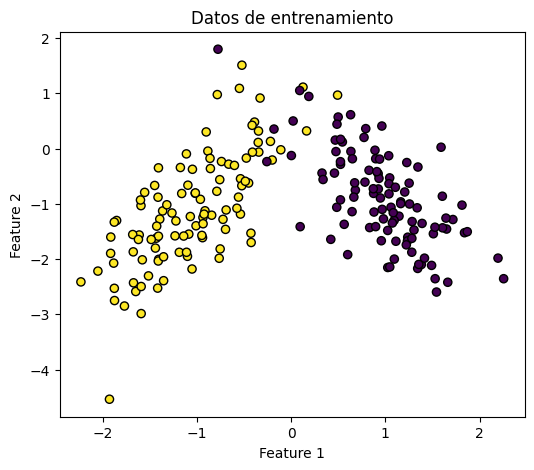

In [51]:
rng = np.random.RandomState(42)

X, y = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

plt.figure(figsize=(6,5))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor="k", s=35)
plt.title("Datos de entrenamiento")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()

## Crear una malla para visualizar el modelo

Para visualizar cómo clasifica el modelo en todo el espacio, creamos una **malla de puntos (grid)** que cubre toda la región donde hay datos.

La idea es la siguiente:

1. Generamos muchos puntos distribuidos por todo el plano
2. Pedimos al modelo que **prediga la clase de cada punto**
3. Pintamos el resultado como un mapa de colores

Esto nos permite ver:

- **La frontera de decisión**
- Qué regiones del espacio pertenecen a cada clase según el modelo

In [18]:
def make_grid(X, step=0.02, pad=1.0):
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid

xx, yy, grid = make_grid(X_train, step=0.02, pad=1.0)

## Fronteras de decisión para distintos valores de k

El parámetro más importante de KNN es **k**, el número de vecinos que participan en la decisión.

Para clasificar un punto nuevo, KNN:

1. Busca los **k puntos más cercanos** del dataset
2. Mira a qué clase pertenecen
3. Asigna la clase mayoritaria

Vamos a visualizar cómo cambia la frontera de decisión para distintos valores de k.

Esto nos permite observar un fenómeno importante:

- **k pequeño → modelo muy flexible (puede sobreajustar)**
- **k grande → modelo más suave (puede infraajustar)**

También mostraremos:

- **Accuracy en train**
- **Accuracy en test**

Esto ayuda a entender el equilibrio entre **overfitting y underfitting**.

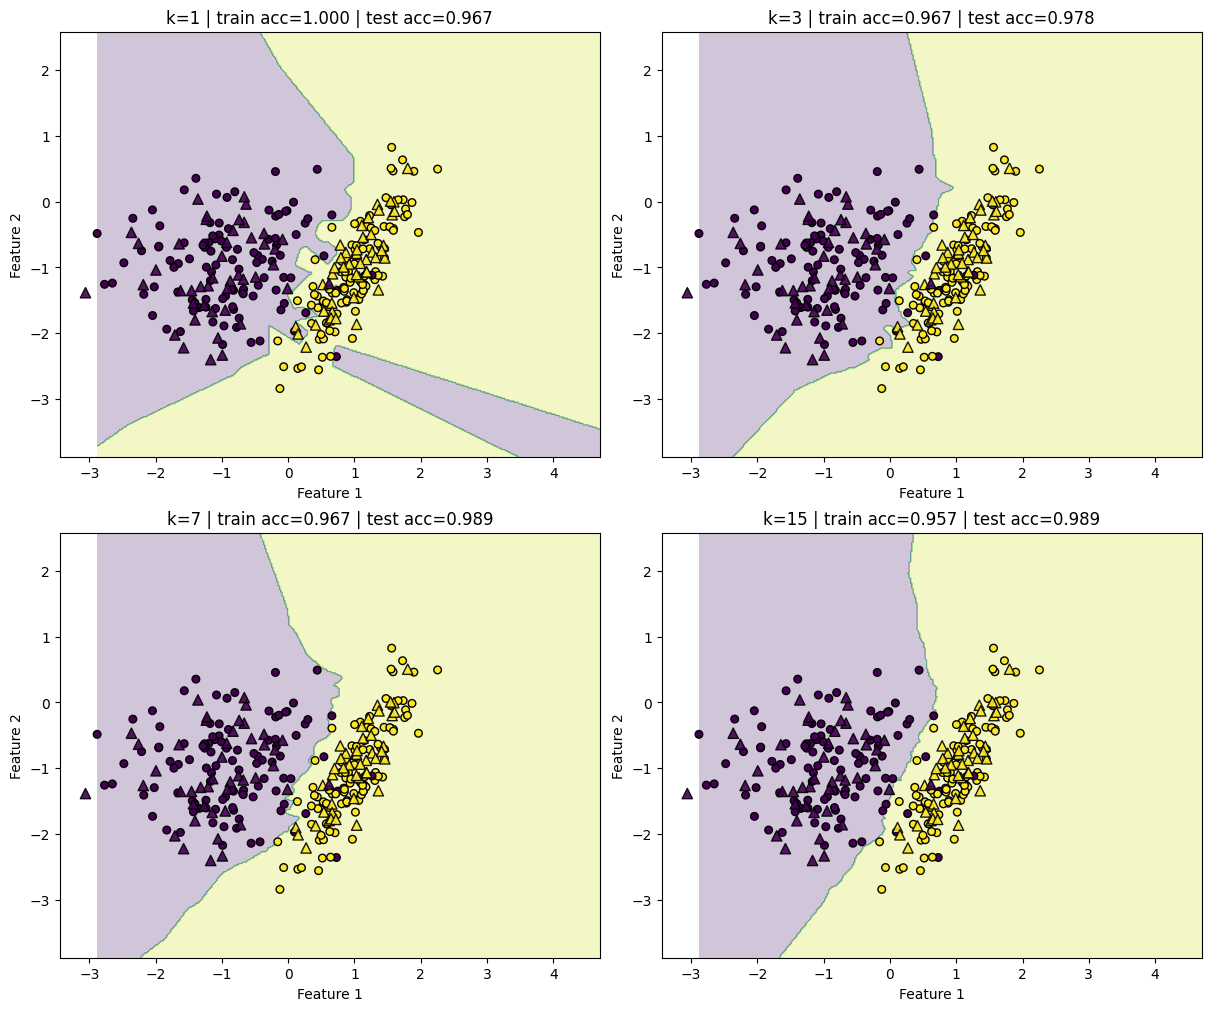

In [21]:
k_values = [1, 3, 7, 15]

fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

for ax, k in zip(axs.flat, k_values):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)

    Z = model.predict(grid).reshape(xx.shape)

    yhat_train = model.predict(X_train)
    yhat_test  = model.predict(X_test)
    acc_train = accuracy_score(y_train, yhat_train)
    acc_test  = accuracy_score(y_test, yhat_test)

    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor="k", s=30)
    ax.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolor="k", s=55, marker="^", alpha=0.9)

    ax.set_title(f"k={k} | train acc={acc_train:.3f} | test acc={acc_test:.3f}")
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

plt.show()

## Probabilidad de clase e incertidumbre

Hasta ahora el modelo solo devuelve **la clase predicha**.

Pero KNN también puede estimar la **probabilidad de pertenecer a cada clase**.

¿Cómo lo hace?

Simplemente calcula la proporción de vecinos de cada clase.

Por ejemplo:

- k = 10
- 7 vecinos son clase 1
- 3 vecinos son clase 0

Entonces:

P(clase 1) = 0.7

En esta visualización veremos un **mapa de probabilidades**, donde los colores indican qué tan seguro está el modelo en cada región.

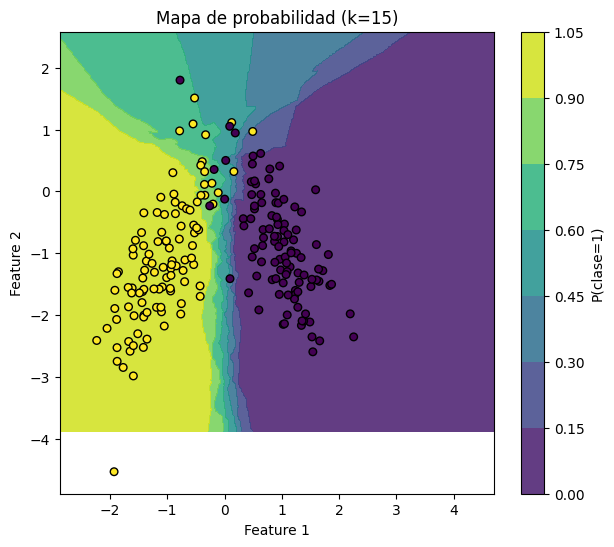

In [52]:
k = 15
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k))
])
model.fit(X_train, y_train)

proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, proba, alpha=0.85)
plt.colorbar(label="P(clase=1)")
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor="k", s=30)
plt.title(f"Mapa de probabilidad (k={k})")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()

## ¿Qué vecinos están decidiendo la clasificación?

Para entender realmente cómo funciona KNN, vamos a hacer algo muy instructivo:

Elegimos **un punto concreto del espacio** y observamos:

- Cuáles son sus **k vecinos más cercanos**
- Qué clases tienen
- Qué predicción produce el modelo

En la gráfica veremos:

- El punto que queremos clasificar
- Los vecinos que participan en la decisión

Esto nos permite visualizar el mecanismo fundamental de KNN:

> El modelo no aprende parámetros: simplemente consulta los ejemplos más cercanos del dataset.

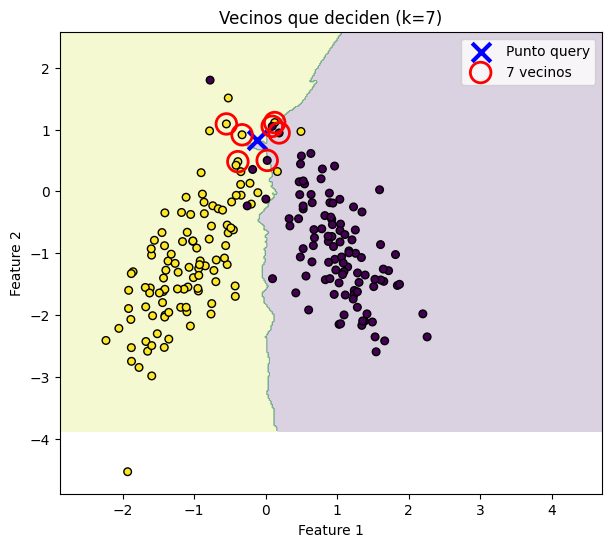

Clases de los vecinos: [1 0 0 0 1 1 1]
Predicción: 1  | Probabilidad clase 1: 0.571


In [66]:
k = 7
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k))
])
knn.fit(X_train, y_train)

# Punto a explicar (puedes cambiarlo)
p = np.random.uniform(-1, 1, (1, 2))

# OJO: kneighbors hay que llamarlo sobre el estimador final (knn.named_steps["knn"]),
# pero en el espacio escalado.
scaler = knn.named_steps["scaler"]
knn_est = knn.named_steps["knn"]

Xtr_s = scaler.transform(X_train)
p_s = scaler.transform(p)

dist, idx = knn_est.kneighbors(p_s, n_neighbors=k)

plt.figure(figsize=(7,6))
Z = knn.predict(grid).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.2)

plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor="k", s=30)
plt.scatter(p[:,0], p[:,1], c="blue", s=180, marker="x", linewidths=3, label="Punto query")

neighbors = X_train[idx[0]]
plt.scatter(neighbors[:,0], neighbors[:,1], facecolors="none", edgecolors="red",
            s=220, linewidths=2, label=f"{k} vecinos")

# Línea visual opcional: círculo aproximado (en espacio original no es exacto por el escalado, pero ayuda)
plt.title(f"Vecinos que deciden (k={k})")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("Clases de los vecinos:", y_train[idx[0]])
print("Predicción:", knn.predict(p)[0], " | Probabilidad clase 1:", knn.predict_proba(p)[0,1].round(3))

## Pesos uniformes vs pesos por distancia

Por defecto, KNN considera que **todos los vecinos tienen el mismo peso**.

Esto significa que un vecino muy cercano y otro más lejano influyen igual en la decisión.

Sin embargo, existe otra opción:

**weights = "distance"**

En este caso:

- Los vecinos **más cercanos tienen más influencia**
- Los vecinos **más lejanos pesan menos**

Vamos a comparar ambas opciones para ver cómo cambian las probabilidades y las fronteras de decisión.

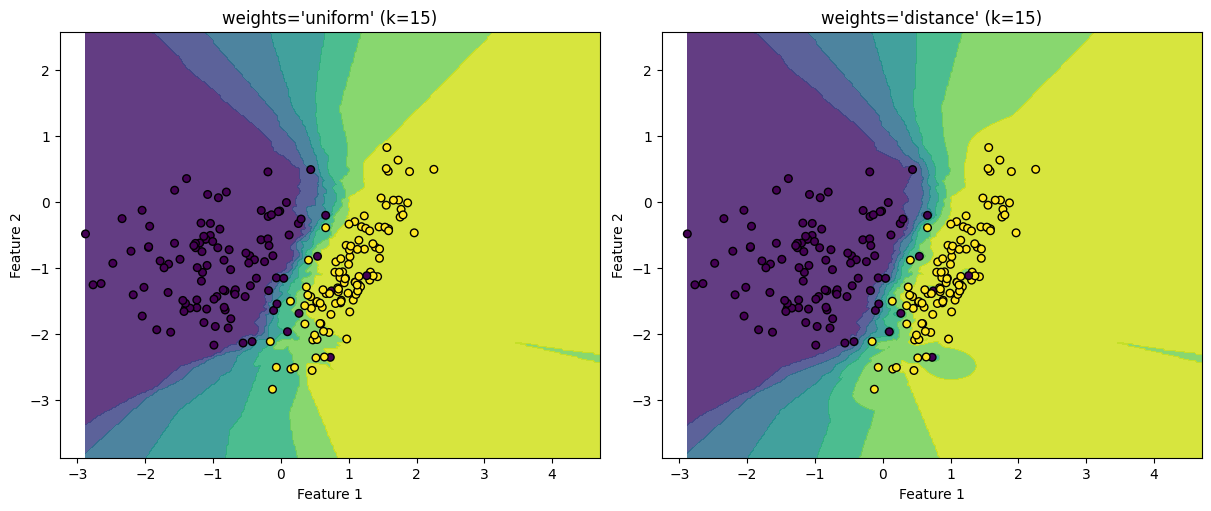

In [26]:
k = 15
fig, axs = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

for ax, w in zip(axs, ["uniform", "distance"]):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights=w))
    ])
    model.fit(X_train, y_train)
    proba = model.predict_proba(grid)[:,1].reshape(xx.shape)

    ax.contourf(xx, yy, proba, alpha=0.85)
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor="k", s=30)
    ax.set_title(f"weights='{w}' (k={k})")
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

plt.show()